# Chebyshev Polynomials

Chebyshev polynomials are a sequence of orthogonal polynomials defined on the interval $[-1,1]$. They are denoted by $T_n(x)$, where $n$ is the polynomial degree. The first few Chebyshev polynomials are

$$
T_0(x) = 1,\quad
T_1(x) = x,\quad
T_2(x) = 2x^2-1,\quad
T_3(x) = 4x^3-3x.
$$

A function can be represented using the Chebyshev basis as

$$
f(x) = \sum_{n=0}^{\infty}a_nT_n(x).
$$

The Chebyshev polynomials are orthogonal on $[-1,1]$ with respect to the weight function

$$
w(x) = \frac{1}{\sqrt{1-x^2}},
$$

so that

$$
\int_{-1}^{1}\frac{T_m(x)T_n(x)}{\sqrt{1-x^2}}\,dx=
\begin{cases}
0, & m \neq n,\\
\pi, & m = n = 0,\\
\frac{\pi}{2}, & m = n \neq 0.
\end{cases}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Chebyshev Expansion

Consider the polynomial

$$
f(x) = x^3 - x^2 - x - 2
$$

over the interval

$$
x\in[-2,2].
$$

In [3]:
x = np.linspace(-2, 2, 1000)
f = x**3 - x**2 - x - 2
deg = 3

A degree-$3$ Chebyshev approximation is obtained using `Chebyshev.fit`:

In [4]:
P = Chebyshev.fit(x, f, deg)
P

Chebyshev([-4.,  4., -2.,  2.], domain=[-2.,  2.], window=[-1.,  1.], symbol='x')

The output

$$
f(x) = -4T_0\left(\frac{x}{2}\right) + 4T_1\left(\frac{x}{2}\right) - 2T_2\left(\frac{x}{2}\right) + 2T_3\left(\frac{x}{2}\right)
$$


shows the coefficients of the Chebyshev expansion. The argument $0.5x$ appears because `Chebyshev.fit` maps the fitting interval $[-2,2]$ to the standard Chebyshev domain $[-1,1]$. Thus, the polynomial is represented in terms of the scaled variable

$$
\xi=\frac{x}{2}.
$$

## Verification

The numerical approximation can be verified using `np.allclose`:

In [5]:
np.allclose(P(x), f)

True

A result of `True` indicates that the Chebyshev representation reproduces the original function within numerical precision.

## Approximation

Finally, the original polynomial and its Chebyshev representation are plotted over the interval $[-2,2]$.

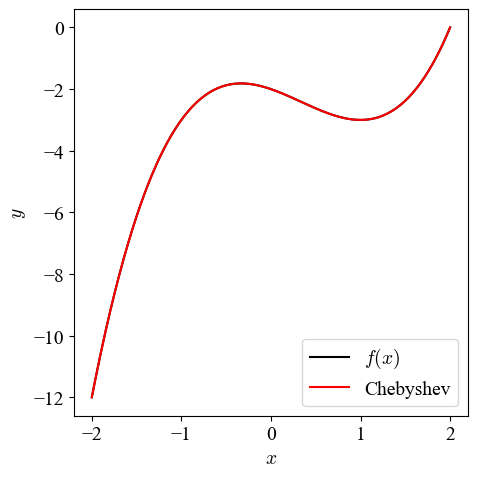

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(x, f, "k", label=r"$f(x)$")
plt.plot(x, P(x), "r", label="Chebyshev")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

Since the two curves overlap, the plot provides a visual confirmation of the numerical result.